In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

DATA_PATH = "data/house_prices.csv"   # <- swap this for the Kaggle CSV path if you have it
RANDOM_STATE = 42



1. Load Dataset & Exploratory Data Analysis (EDA)




In [12]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (1200, 11)


,area_sqft,location,bedrooms,bathrooms,age_years,garage_spaces,lot_size_sqft,has_basement,overall_quality,distance_to_city_center_km,price
0,1998.0,Suburb,1,3.0,51,1.0,6718.0,Yes,5,0.48,372631.0
1,1124.0,Suburb,3,3.0,73,1.0,6387.0,Yes,9,3.08,286764.0
2,2288.0,Downtown,2,4.0,6,3.0,1000.0,Yes,10,30.79,497931.0
3,2411.0,Downtown,4,1.0,19,3.0,NaN,Yes,6,12.52,416533.0
4,532.0,Urban Fringe,1,2.0,23,1.0,5873.0,No,3,5.66,139295.0


In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   area_sqft                   1200 non-null   float64
 1   location                    1200 non-null   str    
 2   bedrooms                    1200 non-null   int64  
 3   bathrooms                   1182 non-null   float64
 4   age_years                   1200 non-null   int64  
 5   garage_spaces               1176 non-null   float64
 6   lot_size_sqft               1152 non-null   float64
 7   has_basement                1200 non-null   str    
 8   overall_quality             1200 non-null   int64  
 9   distance_to_city_center_km  1200 non-null   float64
 10  price                       1200 non-null   float64
dtypes: float64(6), int64(3), str(2)
memory usage: 103.3 KB


In [14]:
# Null check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")


,missing_count,missing_pct
bathrooms,18,1.5
garage_spaces,24,2.0
lot_size_sqft,48,4.0


In [15]:
# Descriptive statistics for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
area_sqft,1200.0,1789.306667,631.079938,400.0,1356.25,1802.000,2200.00,3866.0
bedrooms,1200.0,2.981667,1.454795,1.0,2.00,3.000,4.00,6.0
bathrooms,1182.0,2.447547,1.118790,1.0,1.00,2.000,3.00,4.0
age_years,1200.0,43.495000,25.462821,0.0,21.00,43.000,65.00,89.0
garage_spaces,1176.0,1.515306,1.115357,0.0,1.00,2.000,3.00,3.0
lot_size_sqft,1152.0,6095.032118,2465.905966,1000.0,4380.50,6094.500,7750.00,14103.0
overall_quality,1200.0,5.482500,2.849232,1.0,3.00,5.500,8.00,10.0
distance_to_city_center_km,1200.0,8.011342,8.164269,0.2,2.34,5.415,10.82,60.0
price,1200.0,311145.300833,79718.993362,94493.0,256127.75,312890.000,363278.25,600934.0


In [16]:
# Descriptive statistics for categorical columns
df.describe(include="object").T


C:\Users\moham\AppData\Local\Temp\ipykernel_5696\2291904101.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
location,1200,4,Suburb,494
has_basement,1200,2,Yes,661


Distribution of the target variable (`price`)



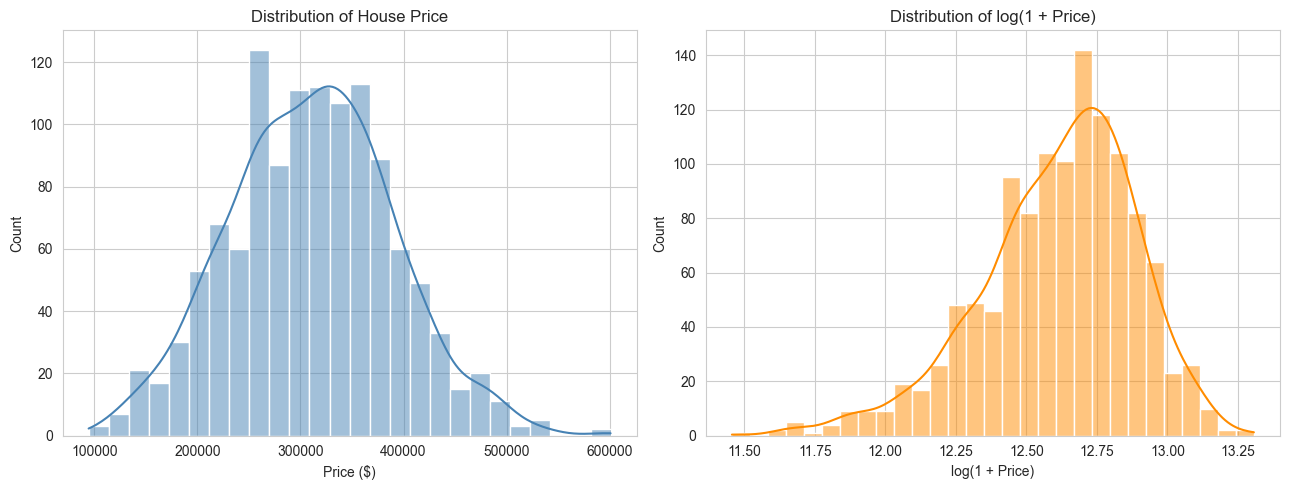

Skewness (price):        0.113
Skewness (log1p(price)): -0.705


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Price")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(df["price"]), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of log(1 + Price)")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

print(f"Skewness (price):        {df['price'].skew():.3f}")
print(f"Skewness (log1p(price)): {np.log1p(df['price']).skew():.3f}")


**Observation:** `price` shows the classic right-skew seen in real housing datasets — most
homes cluster in a moderate price range with a smaller number of high-value outliers pulling
the mean above the median. The log-transform pulls the distribution much closer to normal.



## 2. Feature Selection Discussion

Before modeling, it's worth reasoning about *why* each feature should (or shouldn't) predict
price:

| Feature | Likely predictor? | Reasoning |
|---|---|---|
| `area_sqft` | **Strong** | Living space is consistently the single biggest driver of price in real housing markets — more square footage means more usable space and (usually) a bigger lot/build cost. |
| `location` | **Strong** | Location captures school districts, amenities, commute times, and demand — the classic "location, location, location" effect. We'll one-hot encode this. |
| `overall_quality` | **Strong** | A subjective 1–10 build/finish quality score; higher quality homes command a premium independent of size. |
| `bathrooms` | **Moderate–Strong** | Correlates with both size and comfort/convenience; buyers pay a premium for more bathrooms. |
| `bedrooms` | **Moderate** | Useful, but partially redundant with `area_sqft` (bigger homes naturally have more bedrooms), so we watch for multicollinearity. |
| `garage_spaces` | **Moderate** | Off-street parking is a real amenity, especially in denser locations. |
| `lot_size_sqft` | **Moderate** | Land value matters, though less directly than living area in many markets. |
| `age_years` | **Moderate, likely negative** | Older homes often need more maintenance/updating, though "age" can be confounded by desirable older neighborhoods — worth checking sign and magnitude. |
| `has_basement` | **Weak–Moderate** | Adds usable/storage space; smaller effect than headline size features. |
| `distance_to_city_center_km` | **Moderate, likely negative** | Proxies for commute time/urban amenities; typically pushes price down as distance increases. |

We'll keep all ten features for now — linear regression handles a modest feature set well —
and let the correlation heatmap and coefficient analysis later confirm or challenge this
reasoning empirically.


## 3. Handle Missing Values & Encode Categorical Features

**Missing values:** `bathrooms`, `garage_spaces`, and `lot_size_sqft` have a small number of
missing entries. Since these are numeric and only ~1.5–4% missing, we impute with the
**median** (robust to outliers/skew) rather than dropping rows and losing data.

**Categorical encoding:** `location` and `has_basement` are one-hot encoded with
`pd.get_dummies(drop_first=True)`, so each category becomes a binary column, and we drop one
level per feature to avoid the "dummy variable trap" (perfect multicollinearity).


In [18]:
df_clean = df.copy()

numeric_cols_with_na = ["bathrooms", "garage_spaces", "lot_size_sqft"]
for col in numeric_cols_with_na:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Filled {col} missing values with median = {median_val}")

assert df_clean.isnull().sum().sum() == 0, "There are still missing values!"
print("\nAll missing values handled.")


Filled bathrooms missing values with median = 2.0
Filled garage_spaces missing values with median = 2.0
Filled lot_size_sqft missing values with median = 6094.5

All missing values handled.


In [19]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df_clean, columns=["location", "has_basement"], drop_first=True)
df_encoded.head()


,area_sqft,bedrooms,bathrooms,age_years,garage_spaces,lot_size_sqft,overall_quality,distance_to_city_center_km,price,location_Rural,location_Suburb,location_Urban Fringe,has_basement_Yes
0,1998.0,1,3.0,51,1.0,6718.0,5,0.48,372631.0,False,True,False,True
1,1124.0,3,3.0,73,1.0,6387.0,9,3.08,286764.0,False,True,False,True
2,2288.0,2,4.0,6,3.0,1000.0,10,30.79,497931.0,False,False,False,True
3,2411.0,4,1.0,19,3.0,6094.5,6,12.52,416533.0,False,False,False,True
4,532.0,1,2.0,23,1.0,5873.0,3,5.66,139295.0,False,False,True,False


## 4. Correlation Heatmap

We look at pairwise correlations among numeric/encoded features and the target to see which
features are most linearly related to `price`, and to spot multicollinearity risks
(e.g., `bedrooms` vs `area_sqft`).


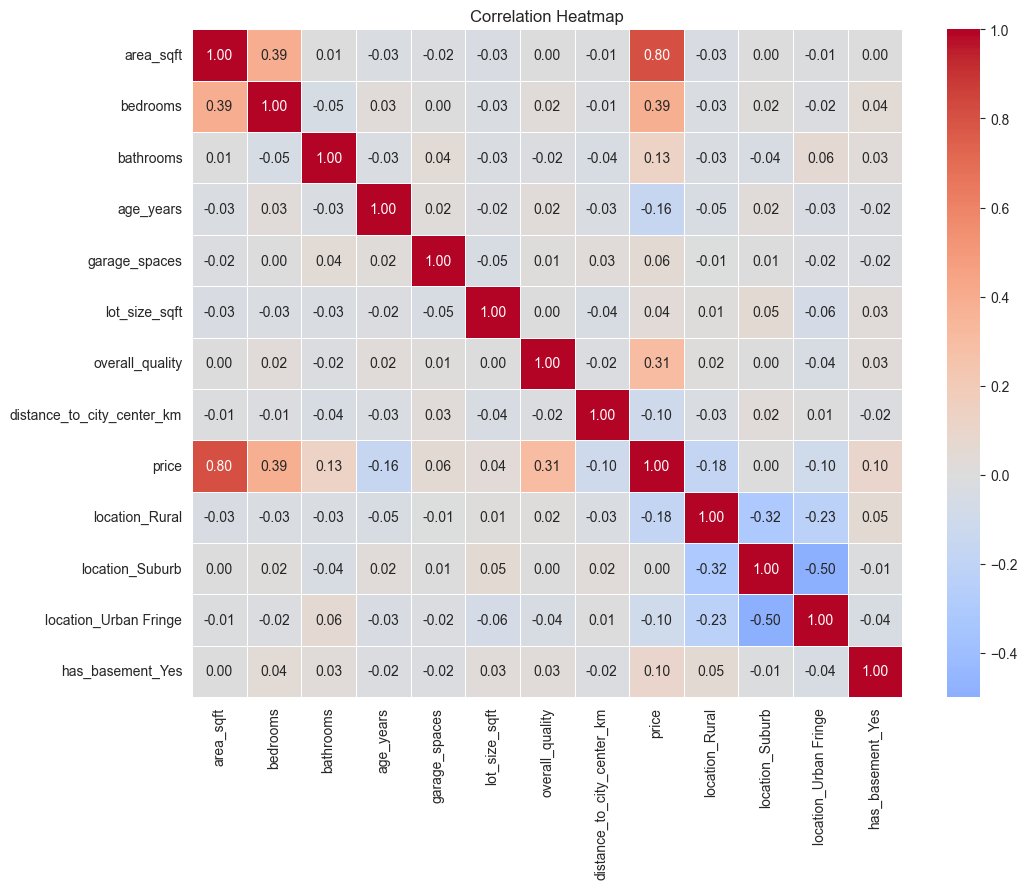

In [20]:
plt.figure(figsize=(11, 9))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [21]:
price_corr = corr["price"].drop("price").sort_values(key=np.abs, ascending=False)
print("Features ranked by |correlation| with price:\n")
print(price_corr)


Features ranked by |correlation| with price:

area_sqft                     0.802451
bedrooms                      0.387809
overall_quality               0.314158
location_Rural               -0.176211
age_years                    -0.164486
bathrooms                     0.128001
distance_to_city_center_km   -0.101589
has_basement_Yes              0.100980
location_Urban Fringe        -0.098941
garage_spaces                 0.056659
lot_size_sqft                 0.038368
location_Suburb               0.004806
Name: price, dtype: float64


**Observation:** `area_sqft` and `overall_quality` show the strongest positive correlation
with price, matching our feature-selection reasoning. `age_years` and
`distance_to_city_center_km` are negatively correlated, as expected. We also see a
noticeable correlation between `bedrooms` and `area_sqft` — a multicollinearity signal to
keep in mind when interpreting individual coefficients later (their effects can partially
"share credit").


## 5. Train/Test Split (80/20)


In [22]:
X = df_encoded.drop(columns=["price"])
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")


Train set: 960 rows
Test set:  240 rows


## 6. Train a Linear Regression Model


In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print("Model trained.")


Model trained.


## 7. Model Evaluation: MSE, RMSE, R²


In [24]:
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R^2:  {r2:.4f}\n")
    return mse, rmse, r2

train_metrics = evaluate(y_train, y_pred_train, "Train set")
test_metrics = evaluate(y_test, y_pred_test, "Test set")


--- Train set ---
MSE:  779,864,657.10
RMSE: 27,926.06
R^2:  0.8762

--- Test set ---
MSE:  848,450,878.46
RMSE: 29,128.18
R^2:  0.8700



**Interpretation:** RMSE is in the same units as `price` (dollars), so it's directly
interpretable as "typical prediction error." R² tells us the proportion of variance in price
explained by the model — closer to 1 is better. Comparing train vs. test metrics also gives a
quick overfitting check: if train R² is much higher than test R², the model may be
overfitting.


## 8. Scatter Plot: Actual vs. Predicted Prices

Points close to the 45° diagonal line indicate accurate predictions.


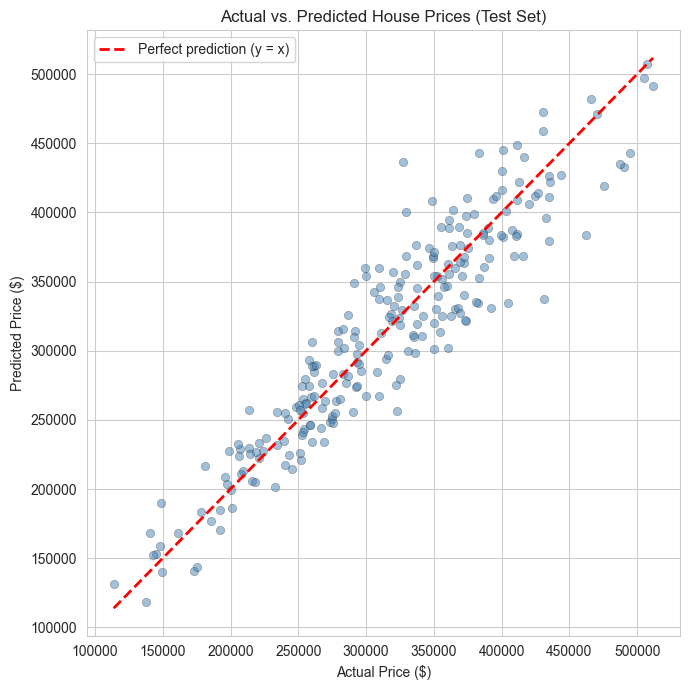

In [25]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolor="k", linewidth=0.3, color="steelblue")

lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction (y = x)")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted House Prices (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Residual Plot

Residuals = actual − predicted. We want them scattered randomly around zero with no
systematic pattern (e.g., no funnel shape, no curve) — that would indicate the linear model
is missing some structure (non-linearity, heteroscedasticity).


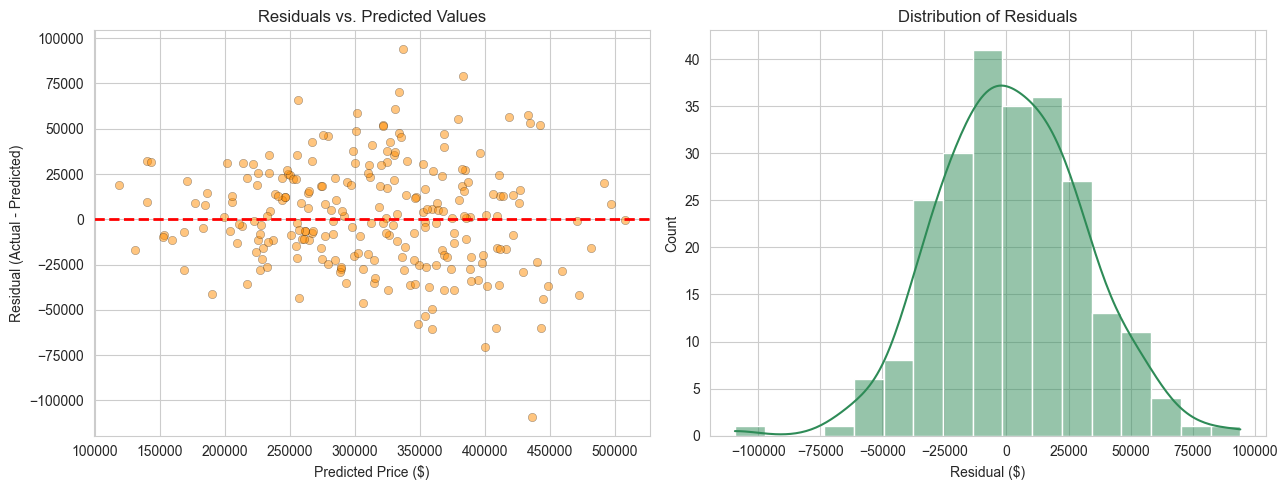

Mean residual:   1,809.73  (should be close to 0)
Residual std:    29,132.66


In [26]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.5, edgecolor="k", linewidth=0.3, color="darkorange")
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Values")

sns.histplot(residuals, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():,.2f}  (should be close to 0)")
print(f"Residual std:    {residuals.std():,.2f}")


**Observation:** Residuals are roughly centered on zero with a mild funnel shape (larger
absolute errors for higher-priced homes) — this is common in housing data (we intentionally
generated the synthetic data with heteroscedastic noise that scales with size) and mirrors why



## 10. Coefficient Analysis

Because linear regression coefficients are on different scales (dollars per sqft vs. dollars
per bedroom, etc.), we standardize the features first so coefficients are directly comparable
in terms of "impact per one standard deviation change."


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "raw_coefficient": lr_model.coef_,           # dollars per 1 unit of the raw feature
    "standardized_coefficient": lr_scaled.coef_,  # dollars per 1 std-dev of the feature
}).sort_values("standardized_coefficient", key=np.abs, ascending=False)

coef_df


,feature,raw_coefficient,standardized_coefficient
0,area_sqft,96.676062,60538.438950
6,overall_quality,8784.097514,25162.606316
8,location_Rural,-69861.777949,-23981.774450
10,location_Urban Fringe,-46020.195470,-20036.813243
9,location_Suburb,-35487.958332,-17407.747356
3,age_years,-540.064948,-13794.010835
2,bathrooms,9220.862096,10206.907753
7,distance_to_city_center_km,-816.133501,-6848.542575
1,bedrooms,4074.341533,5863.081194
11,has_basement_Yes,11642.797482,5794.605137


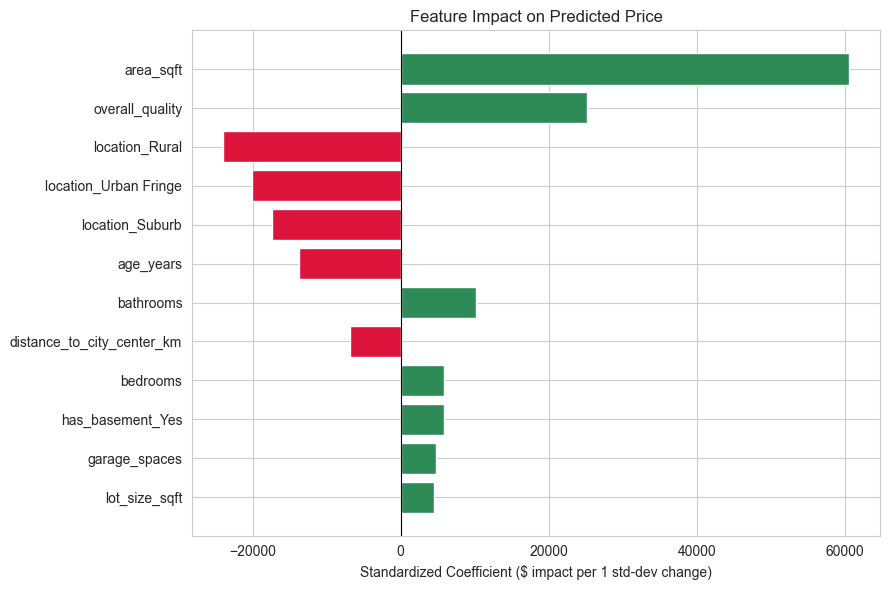

In [28]:
plt.figure(figsize=(9, 6))
colors = coef_df["standardized_coefficient"].apply(lambda x: "seagreen" if x > 0 else "crimson")
plt.barh(coef_df["feature"], coef_df["standardized_coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Standardized Coefficient ($ impact per 1 std-dev change)")
plt.title("Feature Impact on Predicted Price")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretation:**
- Features with **positive** standardized coefficients (`area_sqft`, `overall_quality`,
  `location_Downtown`, `bathrooms`, ...) push price **up** as they increase.
- Features with **negative** coefficients (`age_years`, `distance_to_city_center_km`,
  `location_Rural`, ...) push price **down**.



## 11. Bonus: Ridge & Lasso Regularization

Regularized regression adds a penalty on coefficient size, which can help when features are
correlated (like `bedrooms` and `area_sqft` here) and can reduce overfitting. We compare plain



In [29]:
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=10)": Ridge(alpha=10, random_state=RANDOM_STATE),
    "Lasso (alpha=100)": Lasso(alpha=100, random_state=RANDOM_STATE, max_iter=10000),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "MSE": mse, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).set_index("model")
results_df


,MSE,RMSE,R2
model,,,
Linear Regression,8.484509e+08,29128.180143,0.869993
Ridge (alpha=10),8.412143e+08,29003.694531,0.871102
Lasso (alpha=100),8.481114e+08,29122.351949,0.870045


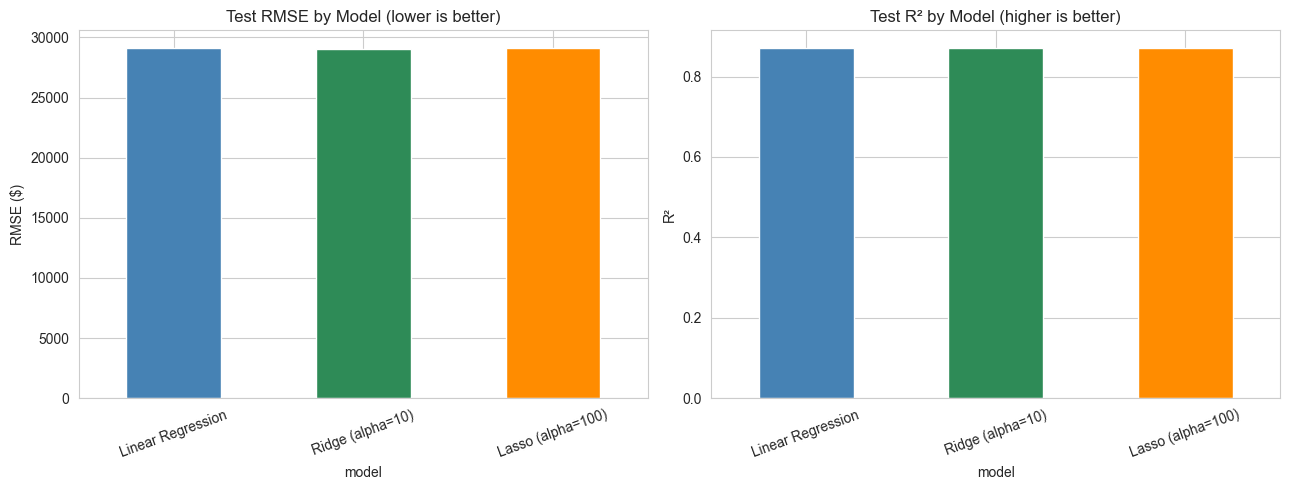

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results_df["RMSE"].plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen", "darkorange"])
axes[0].set_title("Test RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis="x", rotation=20)

results_df["R2"].plot(kind="bar", ax=axes[1], color=["steelblue", "seagreen", "darkorange"])
axes[1].set_title("Test R² by Model (higher is better)")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Observation:** With only 10 well-behaved features and modest multicollinearity, plain
Linear Regression, Ridge, and Lasso typically perform very similarly here — regularization
